# (00) Data Pipeline

In [26]:
!pip install -q datasets pillow tqdm

In [27]:
from pathlib import Path
import os

dataset_path = Path("/kaggle/input/datasets/anannyaumesh/icdar2026/cmmhwr26")

if dataset_path.exists():
    print(f"\n✅ Dataset found at {dataset_path}")
    
    # Count manuscripts
    manuscript_folders = [d for d in dataset_path.iterdir() if d.is_dir()]
    print(f"   Manuscripts found: {len(manuscript_folders)}")
    
    # Show first few
    print("\n   First 5 manuscripts:")
    for mss in list(manuscript_folders)[:5]:
        print(f"     - {mss.name}")
else:
    print(f"\n❌ ERROR: Dataset not found at {dataset_path}")
    print("\n   Please update dataset_path in Cell 2 to match your upload")
    print("   Available paths:")
    !ls -la /kaggle/input/


✅ Dataset found at /kaggle/input/datasets/anannyaumesh/icdar2026/cmmhwr26
   Manuscripts found: 300

   First 5 manuscripts:
     - mss-070
     - mss-049
     - mss-151
     - mss-321
     - mss-060


## 1. Helper Functions

In [28]:
import xml.etree.ElementTree as ET
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from tqdm import tqdm
import unicodedata
from collections import Counter, defaultdict
import random

@dataclass
class TextLineData:
    """Data structure for a single text line"""
    line_id: str
    text: str
    hpos: float
    vpos: float
    width: float
    height: float
    page_image_path: Path
    manuscript_id: str
    page_id: str
    language: str
    xml_source: Path
    line_index: int = 0  # ← ADD THIS: Sequential index within page
    
    @property
    def aspect_ratio(self) -> float:
        """Calculate aspect ratio (width/height)"""
        return self.width / self.height if self.height > 0 else 0
    
    @property
    def unique_line_id(self) -> str:
        """Create globally unique line ID with manuscript + page + line + index"""
        # If line_index > 0, it means this was a duplicate within the page
        if self.line_index > 0:
            return f"{self.manuscript_id}_{self.page_id}_{self.line_id}_{self.line_index}"
        else:
            return f"{self.manuscript_id}_{self.page_id}_{self.line_id}"

@dataclass
class FilterStats:
    """Statistics about filtered lines"""
    total_lines: int = 0
    filtered_lines: int = 0
    filter_reasons: dict = None
    
    def __post_init__(self):
        if self.filter_reasons is None:
            self.filter_reasons = {}
    
    def add_filter(self, reason: str):
        """Record a filtered line"""
        self.filtered_lines += 1
        self.filter_reasons[reason] = self.filter_reasons.get(reason, 0) + 1
    
    def print_summary(self):
        """Print filtering summary"""
        print(f"\n=== Filtering Summary ===")
        print(f"Total lines processed: {self.total_lines:,}")
        print(f"Lines kept: {self.total_lines - self.filtered_lines:,} ({(1 - self.filtered_lines/self.total_lines)*100:.1f}%)")
        print(f"Lines filtered: {self.filtered_lines:,} ({self.filtered_lines/self.total_lines*100:.1f}%)")
        
        if self.filter_reasons:
            print(f"\nFilter breakdown:")
            for reason, count in sorted(self.filter_reasons.items(), key=lambda x: x[1], reverse=True):
                print(f"  {reason:<25} {count:>6,} ({count/self.filtered_lines*100:>5.1f}%)")

print("✅ Data structures defined")

✅ Data structures defined


## 2. Data Loader

In [29]:
def load_metadata(manuscript_folder: Path) -> Dict:
    """Load metadata.json for a manuscript"""
    metadata_file = manuscript_folder / "metadata.json"
    if not metadata_file.exists():
        return {"language": "Unknown", "century": None, "script": None}
    
    with open(metadata_file, 'r', encoding='utf-8') as f:
        return json.load(f)

def extract_lines_from_xml(xml_path: Path, manuscript_folder: Path, metadata: Dict) -> List[TextLineData]:
    """Extract all text lines from a single ALTO XML file"""
    lines = []
    
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        page_id = xml_path.stem
        
        # Get corresponding image file
        image_name = xml_path.stem
        page_image_path = None
        
        for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff']:
            img_path = manuscript_folder / f"{image_name}{ext}"
            if img_path.exists():
                page_image_path = img_path
                break
        
        if page_image_path is None:
            return []
        
        # ✅ Track line IDs to detect duplicates within this page
        line_id_counts = {}
        
        # Extract all TextLine elements
        for text_line in root.findall('.//{*}TextLine'):
            line_id = text_line.get('ID')
            if not line_id:
                continue
            
            # ✅ Count occurrences of this line_id within this page
            if line_id not in line_id_counts:
                line_id_counts[line_id] = 0
            else:
                line_id_counts[line_id] += 1
            
            line_index = line_id_counts[line_id]
            
            hpos = float(text_line.get('HPOS', 0))
            vpos = float(text_line.get('VPOS', 0))
            width = float(text_line.get('WIDTH', 0))
            height = float(text_line.get('HEIGHT', 0))
            
            string_elem = text_line.find('.//{*}String')
            text = string_elem.get('CONTENT', '') if string_elem is not None else ''
            
            line_data = TextLineData(
                line_id=line_id,
                text=text,
                hpos=hpos,
                vpos=vpos,
                width=width,
                height=height,
                page_image_path=page_image_path,
                manuscript_id=manuscript_folder.name,
                page_id=page_id,
                language=metadata.get('language', 'Unknown'),
                xml_source=xml_path,
                line_index=line_index  # ← ADD THIS
            )
            
            lines.append(line_data)
    
    except Exception as e:
        print(f"Error processing {xml_path}: {e}")
    
    return lines

def load_dataset_from_path(dataset_path: Path, limit: int = None):
    """Load entire dataset from all manuscripts"""
    all_lines = []
    stats = {
        'total_manuscripts': 0,
        'total_pages': 0,
        'total_lines': 0,
        'lines_per_language': {},
        'manuscripts_per_language': {},
    }
    
    manuscript_folders = [d for d in dataset_path.iterdir() if d.is_dir()]
    
    if limit:
        manuscript_folders = manuscript_folders[:limit]
    
    print(f"Loading data from {len(manuscript_folders)} manuscripts...")
    
    for manuscript_folder in tqdm(manuscript_folders, desc="Processing manuscripts"):
        stats['total_manuscripts'] += 1
        
        metadata = load_metadata(manuscript_folder)
        language = metadata.get('language', 'Unknown')
        
        stats['manuscripts_per_language'][language] = \
            stats['manuscripts_per_language'].get(language, 0) + 1
        
        xml_files = list(manuscript_folder.glob("*.xml"))
        stats['total_pages'] += len(xml_files)
        
        for xml_file in xml_files:
            lines = extract_lines_from_xml(xml_file, manuscript_folder, metadata)
            stats['total_lines'] += len(lines)
            stats['lines_per_language'][language] = \
                stats['lines_per_language'].get(language, 0) + len(lines)
            all_lines.extend(lines)
    
    print(f"\n✅ Loaded {stats['total_lines']:,} lines from {stats['total_manuscripts']} manuscripts")
    print(f"   Pages processed: {stats['total_pages']:,}")
    print(f"\nLines per language:")
    for lang, count in sorted(stats['lines_per_language'].items(), key=lambda x: x[1], reverse=True):
        print(f"   {lang:<15} {count:>7,} lines")
    
    return all_lines, stats

print("✅ Data loading functions defined")

✅ Data loading functions defined


## 3. Data Filtering

In [30]:
def should_filter_line(text: str, width: float, height: float) -> Tuple[bool, Optional[str]]:
    """Determine if a line should be filtered out"""
    text_stripped = text.strip()
    
    if len(text_stripped) == 0:
        return True, "empty_text"
    
    if len(text_stripped) < 3:
        return True, "text_too_short"
    
    if width < 10 or height < 5:
        return True, "dimensions_too_small"
    
    if width > 7000:
        return True, "width_too_large"
    
    if height > 800:
        return True, "height_too_large"
    
    aspect_ratio = width / height if height > 0 else 0
    if aspect_ratio < 0.5 and len(text_stripped) < 5:
        return True, "suspicious_aspect_ratio"
    
    return False, None

def filter_dataset(lines: list, verbose: bool = True):
    """Filter a list of TextLineData objects"""
    stats = FilterStats(total_lines=len(lines))
    filtered_lines = []
    
    iterator = tqdm(lines, desc="Filtering lines") if verbose else lines
    
    for line in iterator:
        should_filter, reason = should_filter_line(line.text, line.width, line.height)
        
        if should_filter:
            stats.add_filter(reason)
        else:
            filtered_lines.append(line)
    
    if verbose:
        stats.print_summary()
    
    return filtered_lines, stats

def validate_unique_ids(lines: list):
    """Verify that all line IDs are unique after manuscript prefixing"""
    line_ids = [line.unique_line_id for line in lines]
    id_counts = Counter(line_ids)
    duplicates = {lid: count for lid, count in id_counts.items() if count > 1}
    
    if duplicates:
        print(f"\n⚠️  WARNING: Found {len(duplicates)} duplicate line IDs!")
        for lid, count in list(duplicates.items())[:5]:
            print(f"     {lid}: {count} occurrences")
        return False, list(duplicates.keys())
    else:
        print(f"\n✅ All {len(line_ids):,} line IDs are unique!")
        return True, []

print("✅ Filtering functions defined")

✅ Filtering functions defined


## 4. Image Preprocessing

In [31]:
from PIL import Image, ImageEnhance, ImageFilter

def crop_line_from_page(page_image_path: Path, 
                        hpos: float, 
                        vpos: float,
                        width: float, 
                        height: float,
                        margin_ratio: float = 0.05) -> Image.Image:
    """Crop line with margin expansion"""
    page_image = Image.open(page_image_path)
    
    if page_image.mode != 'RGB':
        page_image = page_image.convert('RGB')
    
    # Add margin (5% on all sides)
    margin_h = width * margin_ratio
    margin_v = height * margin_ratio
    
    # Expand bounding box
    hpos_expanded = max(0, hpos - margin_h)
    vpos_expanded = max(0, vpos - margin_v)
    width_expanded = width + (2 * margin_h)
    height_expanded = height + (2 * margin_v)
    
    # Ensure within page boundaries
    page_width, page_height = page_image.size
    right = min(hpos_expanded + width_expanded, page_width)
    bottom = min(vpos_expanded + height_expanded, page_height)
    
    line_image = page_image.crop((hpos_expanded, vpos_expanded, right, bottom))
    
    return line_image


def preprocess_line_image(image: Image.Image, 
                          target_size: int = 384,
                          min_height: int = 48) -> Image.Image:
    """Preprocess with minimum height protection"""
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    
    # Calculate initial dimensions
    if aspect_ratio > 1:
        new_width = target_size
        new_height = int(target_size / aspect_ratio)
    else:
        new_height = target_size
        new_width = int(target_size * aspect_ratio)
    
    # CRITICAL: Enforce minimum height
    if new_height < min_height:
        new_height = min_height
        new_width = int(min_height * aspect_ratio)
        if new_width > target_size:
            new_width = target_size
            new_height = max(int(target_size / aspect_ratio), min_height)
    
    # Resize with high quality
    resized_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Pad to square
    canvas = Image.new('RGB', (target_size, target_size), color=(255, 255, 255))
    paste_x = (target_size - new_width) // 2
    paste_y = (target_size - new_height) // 2
    canvas.paste(resized_image, (paste_x, paste_y))
    
    return canvas


def preprocess_very_wide_line(image: Image.Image,
                               min_height: int = 48) -> Image.Image:
    """Special handling for very wide lines with minimum height"""
    target_width = 384
    target_height = 128
    
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    
    # Calculate dimensions
    if aspect_ratio > (target_width / target_height):
        new_width = target_width
        new_height = int(target_width / aspect_ratio)
    else:
        new_height = target_height
        new_width = int(target_height * aspect_ratio)
    
    # CRITICAL: Enforce minimum height
    if new_height < min_height:
        new_height = min_height
        new_width = int(min_height * aspect_ratio)
        if new_width > target_width:
            new_width = target_width
    
    # Resize
    resized_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Pad to target
    canvas = Image.new('RGB', (target_width, target_height), color=(255, 255, 255))
    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2
    canvas.paste(resized_image, (paste_x, paste_y))
    
    return canvas


def process_line_image(page_image_path: Path, hpos: float, vpos: float,
                       width: float, height: float, target_size: int = 384) -> Image.Image:
    """Complete pipeline: crop + preprocess a line image"""
    line_image = crop_line_from_page(page_image_path, hpos, vpos, width, height)
    
    aspect_ratio = width / height if height > 0 else 0
    
    if aspect_ratio > 15:
        processed = preprocess_very_wide_line(line_image)
    else:
        processed = preprocess_line_image(line_image, target_size=target_size)
    
    return processed

print("✅ Image preprocessing functions defined")

✅ Image preprocessing functions defined


## 5. Text Normalization

In [32]:
def normalize_text(text: str) -> str:
    """Apply NFD normalization as required by competition"""
    return unicodedata.normalize('NFD', text)

print("✅ Text normalization functions defined")

✅ Text normalization functions defined


## 6. Train/Val Split

In [33]:
def create_train_val_split(lines: list, val_ratio: float = 0.2, 
                           random_seed: int = 42, verbose: bool = True):
    """Create train/validation split using hybrid strategy"""
    random.seed(random_seed)
    
    manuscript_groups = defaultdict(list)
    language_manuscripts = defaultdict(set)
    
    for line in lines:
        manuscript_groups[line.manuscript_id].append(line)
        language_manuscripts[line.language].add(line.manuscript_id)
    
    train_lines = []
    val_lines = []
    
    stats = {
        'languages': {},
        'total_train': 0,
        'total_val': 0,
        'split_strategy': {}
    }
    
    for language in sorted(language_manuscripts.keys()):
        manuscripts = list(language_manuscripts[language])
        num_manuscripts = len(manuscripts)
        
        if num_manuscripts == 1:
            manuscript_id = manuscripts[0]
            manuscript_lines = manuscript_groups[manuscript_id]
            train_lines.extend(manuscript_lines)
            
            stats['languages'][language] = {
                'manuscripts': num_manuscripts,
                'train_manuscripts': 1,
                'val_manuscripts': 0,
                'train_lines': len(manuscript_lines),
                'val_lines': 0,
                'strategy': 'all_train_single_manuscript'
            }
            stats['split_strategy'][language] = 'all_train'
            
        else:
            shuffled_manuscripts = manuscripts.copy()
            random.shuffle(shuffled_manuscripts)
            
            num_val_manuscripts = max(1, int(num_manuscripts * val_ratio))
            num_train_manuscripts = num_manuscripts - num_val_manuscripts
            
            train_manuscripts = shuffled_manuscripts[:num_train_manuscripts]
            val_manuscripts = shuffled_manuscripts[num_train_manuscripts:]
            
            lang_train_lines = []
            lang_val_lines = []
            
            for manuscript_id in train_manuscripts:
                lang_train_lines.extend(manuscript_groups[manuscript_id])
            
            for manuscript_id in val_manuscripts:
                lang_val_lines.extend(manuscript_groups[manuscript_id])
            
            train_lines.extend(lang_train_lines)
            val_lines.extend(lang_val_lines)
            
            stats['languages'][language] = {
                'manuscripts': num_manuscripts,
                'train_manuscripts': num_train_manuscripts,
                'val_manuscripts': num_val_manuscripts,
                'train_lines': len(lang_train_lines),
                'val_lines': len(lang_val_lines),
                'strategy': 'manuscript_level_split'
            }
            stats['split_strategy'][language] = 'manuscript_split'
    
    stats['total_train'] = len(train_lines)
    stats['total_val'] = len(val_lines)
    stats['total_lines'] = len(lines)
    stats['actual_val_ratio'] = len(val_lines) / len(lines) if lines else 0
    
    if verbose:
        print("\n=== Train/Val Split Statistics ===")
        print(f"Total lines: {stats['total_lines']:,}")
        print(f"Train lines: {stats['total_train']:,} ({stats['total_train']/stats['total_lines']*100:.1f}%)")
        print(f"Val lines:   {stats['total_val']:,} ({stats['total_val']/stats['total_lines']*100:.1f}%)")
    
    random.shuffle(train_lines)
    random.shuffle(val_lines)
    
    return train_lines, val_lines, stats

def verify_no_leakage(train_lines: list, val_lines: list):
    """Verify there's no data leakage between train and val"""
    train_manuscripts = set(line.manuscript_id for line in train_lines)
    val_manuscripts = set(line.manuscript_id for line in val_lines)
    
    overlap = train_manuscripts & val_manuscripts
    
    if overlap:
        print(f"\n⚠️  WARNING: Data leakage detected!")
        print(f"   {len(overlap)} manuscripts appear in both train and val")
        return False
    else:
        print(f"\n✅ No data leakage: {len(train_manuscripts)} train manuscripts, {len(val_manuscripts)} val manuscripts")
        return True

print("✅ Train/val split functions defined")

✅ Train/val split functions defined


## Run Pipeline on Small Sample

In [34]:
# print("="*80)
print("TESTING PIPELINE ON 5 MANUSCRIPTS")
print("="*80)

# Load sample data
print("\n[1/7] Loading 5 manuscripts...")
lines, load_stats = load_dataset_from_path(dataset_path, limit=300)

# Filter
print("\n[2/7] Filtering...")
filtered_lines, filter_stats = filter_dataset(lines)

# Validate IDs
print("\n[3/7] Validating unique IDs...")
validate_unique_ids(filtered_lines)

# Split
print("\n[4/7] Creating train/val split...")
train_lines, val_lines, split_stats = create_train_val_split(filtered_lines)

# Verify no leakage
verify_no_leakage(train_lines, val_lines)

print("\n✅ Test pipeline complete!")
print(f"   Loaded {len(lines):,} lines")
print(f"   Kept {len(filtered_lines):,} after filtering")
print(f"   Split: {len(train_lines):,} train, {len(val_lines):,} val")

TESTING PIPELINE ON 5 MANUSCRIPTS

[1/7] Loading 5 manuscripts...
Loading data from 300 manuscripts...


Processing manuscripts: 100%|██████████| 300/300 [00:10<00:00, 29.26it/s]



✅ Loaded 144,467 lines from 300 manuscripts
   Pages processed: 2,236

Lines per language:
   French           58,002 lines
   Latin            42,055 lines
   Castilian        33,154 lines
   Italian           8,112 lines
   Catalan           1,597 lines
   Navarrese           739 lines
   Gallician           547 lines
   Venitian            261 lines

[2/7] Filtering...


Filtering lines: 100%|██████████| 144467/144467 [00:00<00:00, 1484215.79it/s]



=== Filtering Summary ===
Total lines processed: 144,467
Lines kept: 139,835 (96.8%)
Lines filtered: 4,632 (3.2%)

Filter breakdown:
  empty_text                 2,378 ( 51.3%)
  text_too_short             2,035 ( 43.9%)
  height_too_large             141 (  3.0%)
  suspicious_aspect_ratio       42 (  0.9%)
  width_too_large               32 (  0.7%)
  dimensions_too_small           4 (  0.1%)

[3/7] Validating unique IDs...

✅ All 139,835 line IDs are unique!

[4/7] Creating train/val split...

=== Train/Val Split Statistics ===
Total lines: 139,835
Train lines: 108,396 (77.5%)
Val lines:   31,439 (22.5%)

✅ No data leakage: 240 train manuscripts, 58 val manuscripts

✅ Test pipeline complete!
   Loaded 144,467 lines
   Kept 139,835 after filtering
   Split: 108,396 train, 31,439 val


## Process Image for Sample

In [35]:
print("\n[5/7] Processing images for sample...")

# Process a small number for testing
sample_train = train_lines[:10] if len(train_lines) > 10 else train_lines
sample_val = val_lines[:5] if len(val_lines) > 5 else val_lines

def process_lines_batch(lines, split_name):
    """Process a batch of lines"""
    processed_data = []
    
    for line in tqdm(lines, desc=f"Processing {split_name}"):
        try:
            image = process_line_image(
                line.page_image_path,
                line.hpos,
                line.vpos,
                line.width,
                line.height,
                target_size=384
            )
            
            normalized_text = normalize_text(line.text)
            
            entry = {
                'image': image,
                'text': normalized_text,
                'line_id': line.unique_line_id,
                'language': line.language,
                'manuscript_id': line.manuscript_id,
                'original_width': line.width,
                'original_height': line.height,
                'aspect_ratio': line.aspect_ratio
            }
            
            processed_data.append(entry)
            
        except Exception as e:
            print(f"\n⚠️  Error processing {line.unique_line_id}: {e}")
            continue
    
    return processed_data

# Process sample
train_data = process_lines_batch(sample_train, "train_sample")
val_data = process_lines_batch(sample_val, "val_sample")

print(f"\n✅ Processed {len(train_data)} training samples")
print(f"✅ Processed {len(val_data)} validation samples")


[5/7] Processing images for sample...


Processing val_sample: 100%|██████████| 5/5 [00:00<00:00,  6.00it/s]


✅ Processed 10 training samples
✅ Processed 5 validation samples


## Create HuggingFace Dataset


[6/7] Creating HuggingFace dataset...

✅ Dataset created!
DatasetDict({
    train: Dataset({
        features: ['image', 'text', 'line_id', 'language', 'manuscript_id', 'original_width', 'original_height', 'aspect_ratio'],
        num_rows: 10
    })
    validation: Dataset({
        features: ['image', 'text', 'line_id', 'language', 'manuscript_id', 'original_width', 'original_height', 'aspect_ratio'],
        num_rows: 5
    })
})

Sample:
  Line ID: mss-187_page-003_eSc_line_c71eba4b
  Text: S ila aus engles deꝑtie
  Language: French
  Image size: (384, 384)


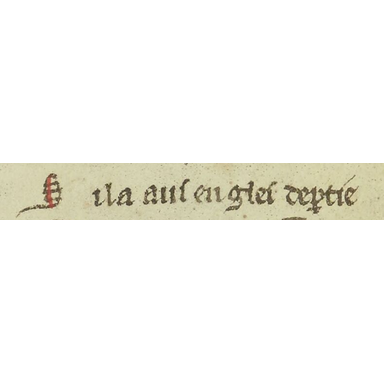

In [36]:
from datasets import Dataset, DatasetDict, Features, Image as HFImage, Value

print("\n[6/7] Creating HuggingFace dataset...")

# Define features schema
features = Features({
    'image': HFImage(),
    'text': Value('string'),
    'line_id': Value('string'),
    'language': Value('string'),
    'manuscript_id': Value('string'),
    'original_width': Value('float32'),
    'original_height': Value('float32'),
    'aspect_ratio': Value('float32')
})

# Create datasets
train_dataset = Dataset.from_list(train_data, features=features)
val_dataset = Dataset.from_list(val_data, features=features)

# Create dataset dict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset
})

print(f"\n✅ Dataset created!")
print(dataset_dict)

# Show sample
sample = train_dataset[0]
print(f"\nSample:")
print(f"  Line ID: {sample['line_id']}")
print(f"  Text: {sample['text']}")
print(f"  Language: {sample['language']}")
print(f"  Image size: {sample['image'].size}")

# Display image
sample['image']

In [37]:
output_dir = Path("/kaggle/working/test_output")
output_dir.mkdir(parents=True, exist_ok=True)

print("\n[7/7] Saving dataset...")
dataset_dict.save_to_disk(output_dir / "hf_dataset")

print(f"\n✅ Dataset saved to {output_dir / 'hf_dataset'}")
print("\n" + "="*80)
print("PIPELINE TEST COMPLETE!")
print("="*80)
print("\nNext: Remove 'limit=5' and run on full dataset")


[7/7] Saving dataset...


Saving the dataset (0/1 shards):   0%|          | 0/10 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5 [00:00<?, ? examples/s]


✅ Dataset saved to /kaggle/working/test_output/hf_dataset

PIPELINE TEST COMPLETE!

Next: Remove 'limit=5' and run on full dataset
